# Naive Bayes model - evaluacija

## 1. Uvod

Naive Bayes (NB) je jednostavan i brz algoritam za klasifikaciju koji se zasniva na Bayesovoj teoremi i pretpostavci nezavisnosti karakteristika. U našem slučaju koristimo GaussianNB, jer su audio karakteristike kontinuirane. NB je pogodan za višeklasne probleme, ali može biti osetljiv na neuravnotežene klase i korelacije među karakteristikama.

## 2. Pretprocesiranje
- Učitavamo audio fajlove sa putanjama i labelama.
- Ekstraktujemo Mel spektrogram.
- Flattenujemo spektrogram u 1D vektor za Naive Bayes.


In [ ]:
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm


df = pd.read_csv("../data/processed_data/audio_labels.csv")
features=[]
for path in tqdm(df['path'], desc="Extracting features"):
    # Ucitaj audio
    y, sr = librosa.load(path, duration=3, sr=44100, offset=0.5, res_type='kaiser_fast')
    
    # Napravi Mel spektrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_db = librosa.power_to_db(mel)
    
    # Očisti NaN i inf vrednosti
    mel_db = np.nan_to_num(mel_db, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Izračunaj statistike po vremenskoj osi (axis=1)
    mean_features = np.mean(mel_db, axis=1)
    std_features  = np.std(mel_db, axis=1)
    max_features  = np.max(mel_db, axis=1)
        
    # Spoji u jedan feature vektor
    feature_vector = np.concatenate([mean_features,std_features,max_features])
    
    features.append(feature_vector)

## 3. Split podataka i skaliranje
- 70% trening, 15% validacija, 15% test.
- Standardizacija svih feature-a (StandardScaler).
- Kodiranje labela u integer vrednosti (LabelEncoder).

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['emotion'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['emotion'])

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Encode labels
le = LabelEncoder()
# Ako su y_train već integeri 0..7, ovo samo osigurava da LabelEncoder ima imena emocija
le.fit(['neutral', 'calm', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise'])

y_val_str  = le.inverse_transform(y_val)
y_val_pred_str = le.inverse_transform(y_val_pred)
y_test_str = le.inverse_transform(y_test)
y_test_pred_str = le.inverse_transform(y_test_pred)

## 4. Treniranje Naive Bayes modela
- Trening Naive Bayes modela započinje standardizacijom karakteristika korišćenjem StandardScaler, čime se sve karakteristike centriraju i skaliraju da imaju standardnu devijaciju.
- Zatim se primenjuje PCA kako bi se dimenzionalnost smanjila na 50 glavnih komponenti, što uklanja šum i smanjuje korelacije među karakteristikama, približavajući podatke pretpostavci nezavisnosti modela. 
- GaussianNB se potom trenira na transformisanim podacima, učeći verovatnoće karakteristika za svaku klasu. 

In [ ]:
scaler = StandardScaler()
X_train_trans = scaler.fit_transform(X_train)
X_val_trans  = scaler.transform(X_val)
X_test_trans  = scaler.transform(X_test)

pca = PCA(n_components=50)
X_train_trans = pca.fit_transform(X_train_trans)
X_val_trans   = pca.transform(X_val_trans)
X_test_trans=pca.transform(X_test_trans)

# =========================
# LABEL ENCODER (samo za imena emocija)
# =========================
le = LabelEncoder()
le.fit(['neutral', 'calm', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise'])

# =========================
# TRAIN GAUSSIAN NAIVE BAYES
# =========================
nb = GaussianNB()
nb.fit(X_train_trans, y_train)

# =========================
# PREDICTIONS
# =========================
y_val_pred = nb.predict(X_val_trans)
y_test_pred = nb.predict(X_test_trans)

## 5. Evaluacija modela
- Računamo tačnost (accuracy) i detaljan classification report.
- Crtamo konfuzione matrice za test skup.
- Evaluacija uključuje:
    - Accuracy (tačnost) – koliko ukupno ispravno klasifikovanih instanci.
    - Precision, Recall, F1-score po klasama – daje uvid koje emocije model bolje ili lošije prepoznaje.
    - Confusion matrix – vizualni pregled grešaka po klasama.
- Rezultati pokazuju da model najbolje prepoznaje dominantne klase, dok slabije performanse imaju retke ili slične emocije.

Test Accuracy: 0.4537037037037037
              precision    recall  f1-score   support

       angry       0.77      0.71      0.74        28
        calm       0.59      0.45      0.51        29
     disgust       0.44      0.48      0.46        29
        fear       0.54      0.48      0.51        29
       happy       0.34      0.38      0.36        29
     neutral       0.19      0.21      0.20        14
         sad       0.22      0.17      0.19        29
    surprise       0.46      0.62      0.53        29

    accuracy                           0.45       216
   macro avg       0.44      0.44      0.44       216
weighted avg       0.46      0.45      0.45       216



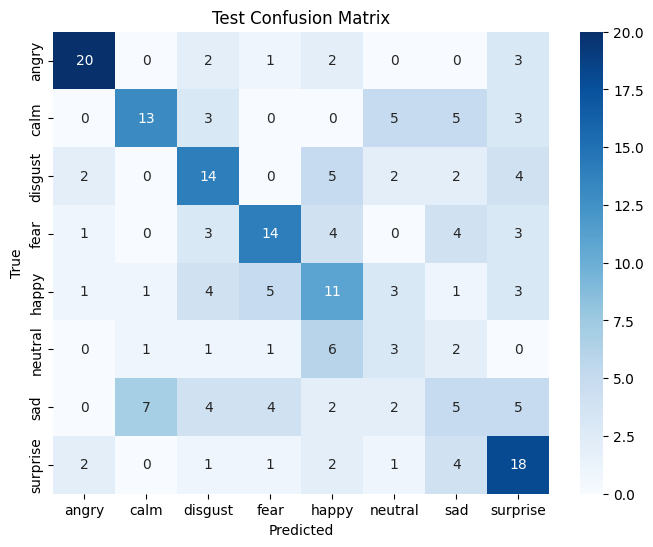

In [4]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD TEST DATA
# =========================
X_test  = np.load("data/processed_data/knn_and_nb/X_test.npy")
y_test  = np.load("data/processed_data/knn_and_nb/y_test.npy")

# =========================
# LOAD SAVED MODEL AND TRANSFORMERS
# =========================
nb = joblib.load("models/naive_bayes/naive_bayes_model.pkl")
scaler = joblib.load("models/naive_bayes/scaler.pkl")
le = joblib.load("models/naive_bayes/label_encoder.pkl")
pca = joblib.load("models/naive_bayes/pca.pkl")  # Ako si PCA sačuvao

# =========================
# TRANSFORM TEST DATA
# =========================
X_test_trans = scaler.transform(X_test)
X_test_trans = pca.transform(X_test_trans)  # PCA transformacija

# =========================
# PREDICTIONS
# =========================
y_test_pred = nb.predict(X_test_trans)

# =========================
# DECODE LABELS
# =========================
y_test_str = le.inverse_transform(y_test)
y_test_pred_str = le.inverse_transform(y_test_pred)

# =========================
# ACCURACY & REPORT
# =========================
print("Test Accuracy:", accuracy_score(y_test_str, y_test_pred_str))
print(classification_report(y_test_str, y_test_pred_str, target_names=le.classes_))

# =========================
# SAVE CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_test_pred, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Confusion Matrix')
plt.show()


## * Augmentacija audio podataka

Augmentacija podataka je tehnika kojom veštački povećavamo broj trening uzoraka bez dodatnog sakupljanja novih podataka.  
Ovo je posebno korisno kod **audio klasifikacije** kada imamo mali ili neuravnotežen dataset.

### Zašto radimo augmentaciju:
- Pomaže modelu da **generalizuje** bolje.
- Smanjuje **overfitting**.
- Omogućava modelu da bude robustan na različite varijacije u audio signalu.

### Popularne tehnike za audio:
1. **Dodavanje šuma (Noise Injection)**  
   - Generiše se slučajan šum koji se dodaje originalnom signalu.  
   - Primer: `y_noisy = y + 0.005 * np.random.randn(len(y))`

2. **Pomak u vremenu (Time Shifting)**  
   - Signal se pomera unapred ili unazad za nekoliko milisekundi.  
   - Očuvava osnovne karakteristike, ali menja početak zvuka.

3. **Promena visine tona (Pitch Shifting)**  
   - Signal se podiže ili spušta za nekoliko polustepena.  
   - Model postaje robustan na različite tonove glasa.

4. **Promena brzine (Time Stretching)**  
   - Produžavanje ili skraćivanje trajanja zvuka bez promene visine tona.  
   - Korisno za varijacije govora ili muzike.

### Kako primenjujemo u praksi:
- Augmentaciju primenjujemo **samo na trening set**, nikada na validaciju ili test.  
- Možemo kombinovati više tehnika da stvorimo **bogatije trening podatke**.  
- Rezultat augmentacije je novi audio signal koji se koristi za ekstrakciju feature-a (npr. Mel spektrogram ili MFCC).

> * Napomena: Preterana augmentacija može dovesti do "lažnih" uzoraka koji zbunjuju model. Treba balansirati količinu i tip augmentacije.


In [ ]:
def add_noise(data, noise_factor=0.005):
    return data + noise_factor * np.random.randn(len(data))

def time_shift(data, shift_max=0.2):
    shift = np.random.randint(int(len(data) * -shift_max), int(len(data) * shift_max))
    return np.roll(data, shift)

def stretch(data, rate=None):
    if rate is None:
        rate = np.random.uniform(0.8, 1.2)
    return librosa.effects.time_stretch(data, rate=rate)

def pitch_shift(data, sr, n_steps=None):
    if n_steps is None:
        n_steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(data, sr=sr, n_steps=n_steps)

def dynamic_change(data):
    factor = np.random.uniform(0.7, 1.3)
    return data * factor

## Rezultat pre augmentacije

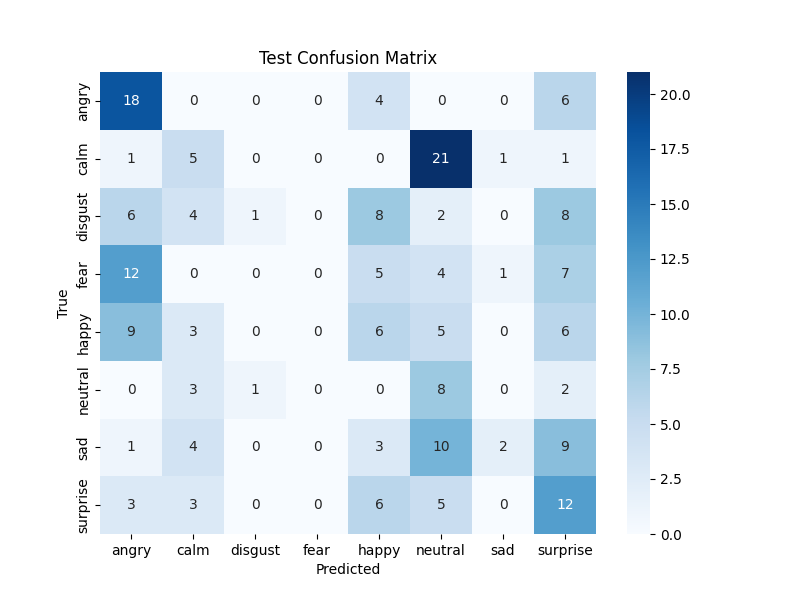

In [3]:
from IPython.display import Image, display

# Ime slike 
init = "models/naive_bayes/init_test_confusion_matrix.png"
# Prikaz slike
display(Image(filename=init))

## Zaključak – Naive Bayes

Naše testiranje Naive Bayes modela na audio dataset-u pokazalo je **tačnost od 45%**. Model je najbolje prepoznao emocije *angry* (precision 0.77, recall 0.71) i *surprise* (precision 0.46, recall 0.62), dok su emocije poput *neutral* (precision 0.19, recall 0.21), *sad* (precision 0.22, recall 0.17) i *happy* (precision 0.34, recall 0.38) bile slabo klasifikovane.

Ovo je očekivano jer GaussianNB pretpostavlja nezavisnost karakteristika, što kod audio signala sa MFCC, pitch i ZCR karakteristikama nije uvek tačno. Model daje brzu baznu liniju za klasifikaciju, ali pokazuje ograničenja kod neuravnoteženih klasa i međusobno zavisnih karakteristika.

Za poboljšanje performansi moglo bi se razmotriti:  
- korišćenje složenijih modela poput KNN ili neuralnih mreža,  
- balansiranje dataset-a i/ili težinsko prilagođavanje klasa.

Generalno, Naive Bayes omogućava brz i jednostavan pregled performansi, ali za precizno prepoznavanje emocija iz zvuka preporučuje se korišćenje modela koji bolje hvataju međuzavisnosti karakteristika.
